In [1]:
# Use Python 3.12.3

import pandas as pd
import numpy as np
import nfl_data_py as nfl
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# seasons = range(2006, 2024)     #Passing stats started in 2006
pbp_py = nfl.import_pbp_data([2023])

2023 done.
Downcasting floats.


In [5]:
len(pbp_py)

49665

<h2>Crosstab Analysis</h2>

In [39]:
#Select relevant features
game_situation = ["yardline_100", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive", "qtr", "down", "ydstogo", "score_differential", "xpass"] 
offensive = ["offense_formation", "offense_personnel"]
defensive = ["defenders_in_box", "defense_personnel", "number_of_pass_rushers", "defense_man_zone_type", "defense_coverage_type"]
play_type = ["play_type", "run_location", "run_gap", "pass_location", "pass_length"]

df = pbp_py[game_situation + offensive + defensive + play_type]

# Chose only run and pass plays
df = df.dropna(subset=["yardline_100", "play_type"]).reset_index(drop=True)
df = df.loc[df['play_type'].isin(['run', 'pass'])]

df_combined = df.copy()

# Put together offensive play call
def combine_columns(row):
    if row['play_type'] == 'run':
        return f"{row['play_type']}_{row['run_location']}_{row['run_gap']}"
    elif row['play_type'] == 'pass':
        return f"{row['play_type']}_{row['pass_location']}_{row['pass_length']}"
    else:
        return None  # or any default value

df_combined['offensive_play'] = df_combined.apply(combine_columns, axis=1)

# Remove plays that result in successful defensive stop
df_combined = df_combined[~df_combined['offensive_play'].isin(['run_right_None', 'run_middle_None', 'pass_None_None', 'run_None_None'])]

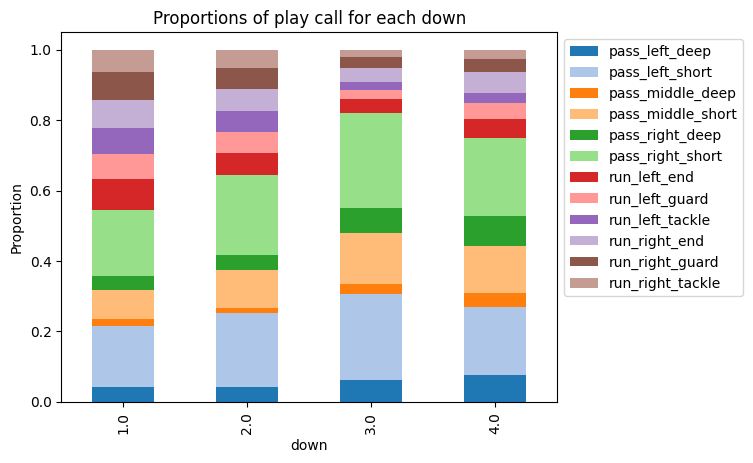

In [40]:
custom_palette = sns.color_palette("tab20", 12)

pd.crosstab(df_combined['down'], df_combined['offensive_play'], normalize="index").plot(kind='bar', stacked=True, color=custom_palette)
plt.title("Proportions of play call for each down")
plt.xlabel("down")
plt.ylabel("Proportion")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
# sns.boxplot(data=df_combined, x='offensive_play', y='ydstogo')

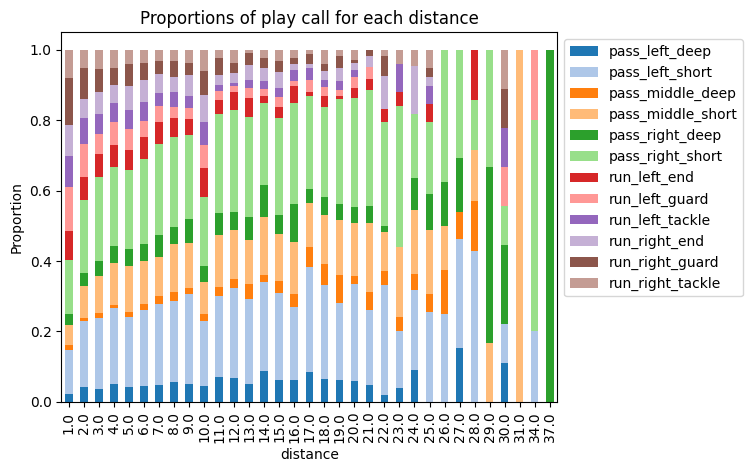

In [41]:
pd.crosstab(df_combined['ydstogo'], df_combined['offensive_play'], normalize="index").plot(kind='bar', stacked=True, color=custom_palette)
plt.title("Proportions of play call for each distance")
plt.xlabel("distance")
plt.ylabel("Proportion")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

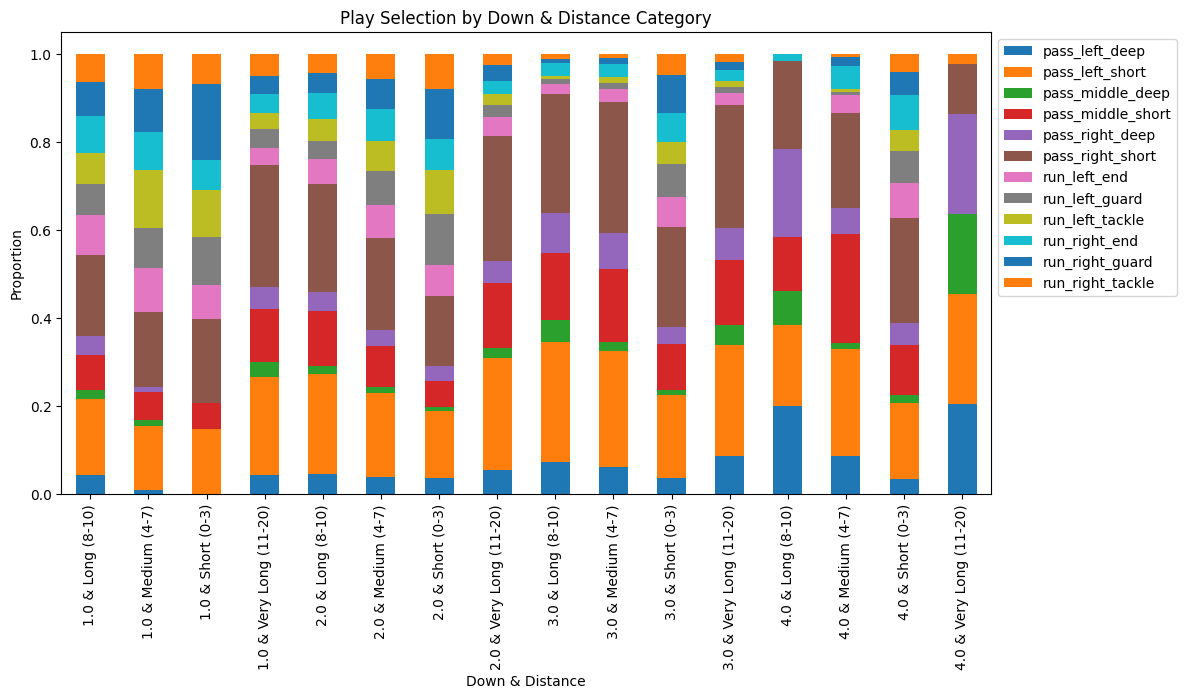

In [52]:
df_combined['distance_bin'] = pd.cut(df_combined['ydstogo'], bins=[0, 3, 7, 10, 20], labels=['Short (0-3)', 'Medium (4-7)', 'Long (8-10)', 'Very Long (11-20)'])
df_combined['distance_bin'][:10]
df_combined = df_combined.dropna(subset=['distance_bin'])
df_combined['down_distance'] = df_combined['down'].astype(str) + ' & ' + df_combined['distance_bin'].astype(str)

pd.crosstab(df_combined['down_distance'], df_combined['offensive_play'], normalize='index').plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Play Selection by Down & Distance Category')
plt.ylabel('Proportion')
plt.xlabel('Down & Distance')
# plt.xticks(rotation=45)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

<h2>Statistical Significance Tests</h2>

In [59]:
from sklearn.feature_selection import mutual_info_classif

X = df_combined[game_situation]  # Must be numeric or encoded
y = df_combined['offensive_play']                 # Target must be categorical (encoded)

# Encode target if it's not already
from sklearn.preprocessing import LabelEncoder
y_encoded = LabelEncoder().fit_transform(y)

mi = mutual_info_classif(X, y_encoded, discrete_features='auto')
for col, score in zip(X.columns, mi):
    print(f"{col}: {score}")


yardline_100: 0.019825605554987913
quarter_seconds_remaining: 0.00939651213106929
half_seconds_remaining: 0.01172368069766705
game_seconds_remaining: 0.019369869193185618
drive: 0.0051405173802812065
qtr: 0.00638591036511027
down: 0.024023601575446918
ydstogo: 0.018681007709066666
score_differential: 0.0071284080527469484
xpass: 0.11590008722280665


In [61]:
from scipy.stats import f_oneway

groups = [group['ydstogo'].dropna() for name, group in df_combined.groupby('offensive_play')]
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 28.903120609034733, p-value: 3.212821218195869e-61


<h2>EPA Analysis</h2>

In [3]:
pbp_run = pbp_py.query('play_type == "run" & rusher_id.notnull()').reset_index()
pbp_run.groupby(["season"]).agg({"rushing_yards" : ["mean", "sum"]}) # simple breakdown
run_brkdwn = pbp_run.groupby(["season", "run_location", "run_gap"]).agg({"rushing_yards" : ["mean", "sum"], "epa": ["mean"]}) # breakdown of run location/gap

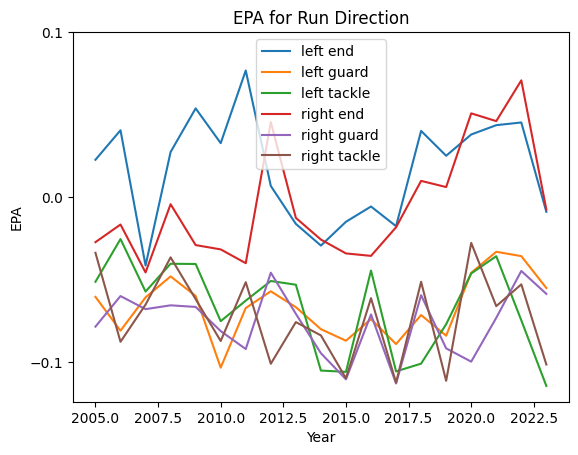

In [ ]:
run_gap = ["end", "guard", "tackle"]
run_side = ["left", "right"]

for j in run_side:
    for i in run_gap:
        run_direction = run_brkdwn.loc[(slice(None), j, i), :].reset_index()
        plt.plot(run_direction["season"], run_direction['epa'], label=f'{j} {i}')
f
plt.title("EPA for Run Direction")
plt.xlabel("Year")
plt.ylabel("EPA")
plt.yticks([-.1, 0, .1])
plt.legend()
plt.show()

In [5]:
pbp_pass = pbp_py.query('play_type == "pass" & passer_id.notnull()').reset_index()
pbp_pass.groupby(["season"]).agg({"passing_yards" : ["mean", "sum"]}) # simple breakdown
pass_brkdwn = pbp_pass.groupby(["season", "pass_location", "pass_length"]).agg({"passing_yards" : ["mean", "sum"], "epa" : ["mean"]})

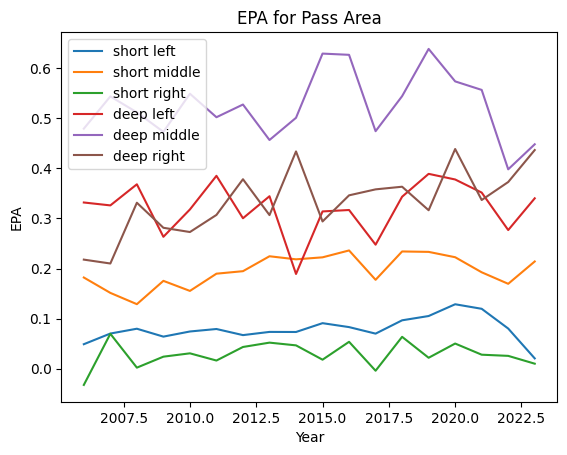

In [6]:
pass_location = ["left", "middle", "right"]
pass_length = ["short", "deep"]

for j in pass_length:
    for i in pass_location:
        pass_area = pass_brkdwn.loc[(slice(None), i, j), :].reset_index()
        plt.plot(pass_area["season"], pass_area['epa'], label=f'{j} {i}')

plt.title("EPA for Pass Area")
plt.xlabel("Year")
plt.ylabel("EPA")
plt.legend()
plt.show()

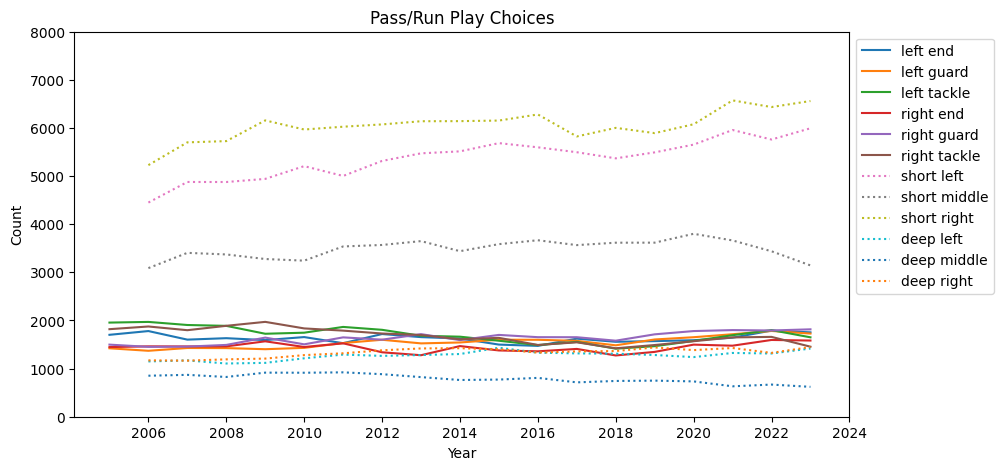

In [33]:
run_counts = pbp_run.groupby(["season", "run_location", "run_gap"]).agg({"index": ["count"]})
pass_counts = pbp_pass.groupby(["season", "pass_location", "pass_length"]).agg({"index": ["count"]})

run_gap = ["end", "guard", "tackle"]
run_side = ["left", "right"]

plt.figure(figsize=(10, 5))

for j in run_side:
    for i in run_gap:
        run_direction = run_counts.loc[(slice(None), j, i), :].reset_index()
        plt.plot(run_direction["season"], run_direction['index'], label=f'{j} {i}')

pass_location = ["left", "middle", "right"]
pass_length = ["short", "deep"]

for j in pass_length:
    for i in pass_location:
        pass_area = pass_counts.loc[(slice(None), i, j), :].reset_index()
        plt.plot(pass_area["season"], pass_area['index'], linestyle=":",label=f'{j} {i}')
    
plt.title("Pass/Run Play Choices")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(np.arange(2006, 2025, 2))
plt.yticks(np.linspace(0, 8000, 9))
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()